In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/processed/clean_transactions.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df.shape

(397885, 9)

In [3]:
SNAPSHOT_DATE = pd.Timestamp('2011-12-10')

In [4]:
rfm = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (SNAPSHOT_DATE - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

In [5]:
rfm.shape

(4338, 4)

In [6]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,18,1,1757.55
4,12350,310,1,334.40


In [7]:
print(rfm.describe())

        Customer ID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.059474     4.272015    2054.270609
std     1721.808492   100.012264     7.697998    8989.229895
min    12346.000000     0.000000     1.000000       3.750000
25%    13813.250000    17.000000     1.000000     307.415000
50%    15299.500000    50.000000     2.000000     674.485000
75%    16778.750000   141.750000     5.000000    1661.740000
max    18287.000000   373.000000   209.000000  280206.020000


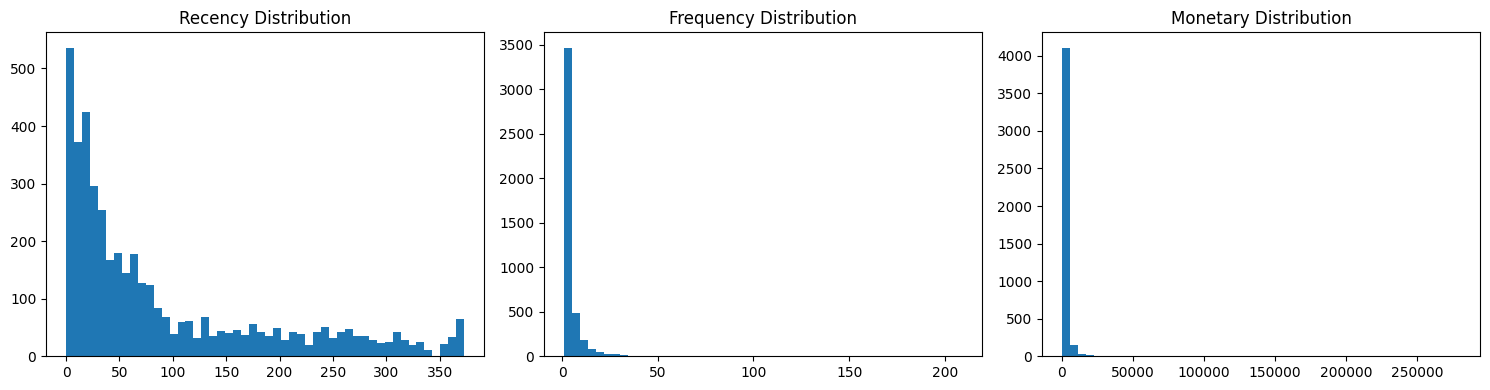

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(rfm['Recency'], bins=50)
axes[0].set_title('Recency Distribution')

axes[1].hist(rfm['Frequency'], bins=50)
axes[1].set_title('Frequency Distribution')


axes[2].hist(rfm['Monetary'], bins=50)
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.savefig('../outputs/figures/rfm_raw_distributions.png', dpi=150)
plt.show()





## Log transformation to reduce the skew 
**Note**: np.log1p to handle log(0) errors

In [9]:
rfm_log = rfm.copy()

In [10]:
rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

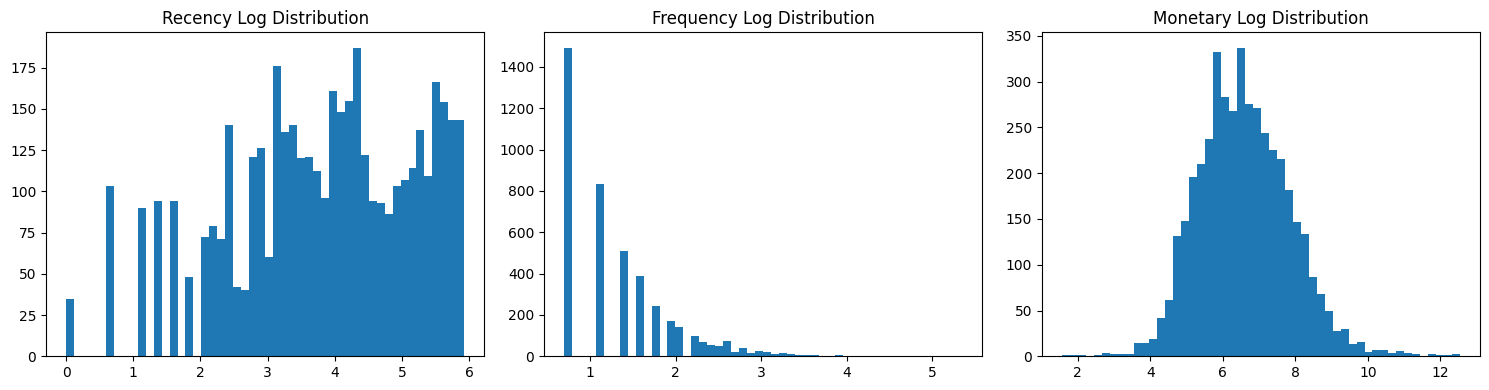

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

axes[0].hist(rfm_log['Recency'], bins=50)
axes[0].set_title('Recency Log Distribution')

axes[1].hist(rfm_log['Frequency'], bins=50)
axes[1].set_title('Frequency Log Distribution')


axes[2].hist(rfm_log['Monetary'], bins=50)
axes[2].set_title('Monetary Log Distribution')

plt.tight_layout()
plt.savefig('../outputs/figures/rfm_log_distributions.png', dpi=150)
plt.show()

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm_log[['Recency', 'Frequency', 'Monetary']])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

## Why Log Transform then Scale

RFM features are right skewed. Log transformation compresses extreme 
values and makes distributions more symmetric. StandardScaler then 
puts all three features on the same scale so KMeans treats them equally. 
Skipping either step would let outliers and scale differences distort 
cluster shapes.

In [18]:
rfm.to_csv('../data/processed/rfm_features.csv', index=False)
rfm_scaled.to_csv('../data/processed/rfm_scaled.csv', index=False)

In [19]:
import pickle

with open('../data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Scaler saved to disk. Must be reused for any new data inference. 
Never refit on new data.